In [12]:
import mlflow
import pandas as pd
import os

IS_PUBLIC = True #TBD
URIS = {
    "name": "uri" # TBD
}

if IS_PUBLIC:
    os.environ["MLFLOW_TRACKING_USERNAME"] = "..." #TBD
    os.environ["MLFLOW_TRACKING_PASSWORD"] = "..." #TBD
    mlflow.set_tracking_uri("https://mlflow.rationai.cloud.e-infra.cz/")

dfs = { k: pd.read_csv(mlflow.artifacts.download_artifacts(uri) ) for k, uri in URIS.items() }

In [3]:
def carcinoma_counts(metadata: pd.DataFrame) -> tuple[int, int]:
    return ( len( metadata[ metadata[ "carcinoma" ] == True ] ) ), ( len( metadata[ metadata[ "carcinoma" ] == False ] ) )

In [6]:
import math

for name, df in dfs.items():
    print( name, len(df), carcinoma_counts(df) )

karolinska_calibration 544 (352, 192)
karolinska_test 4898 (3170, 1728)
karolinska_total 5442 (3522, 1920)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_gs_distr(dfs: dict[str, pd.DataFrame]) -> None:

    def gleason_sort_key(s: str) -> tuple[int, int]:
        if s.lower() == "negative":
            return (-1, 0)  # always first
        parts = s.split("+")
        return (int(parts[0]), int(parts[1]))

    # Compute normalized value counts for each df
    counts_per_df = {name: df["gleason_score"].value_counts(normalize=True)
                      for name, df in dfs.items()}

    # Union of all categories across all dfs, sorted consistently
    all_categories = set()
    for counts in counts_per_df.values():
        all_categories.update(counts.index)
    sorted_categories = sorted(all_categories, key=gleason_sort_key)

    # Align each df's counts to the shared category order (missing -> 0)
    aligned = {
        name: counts.reindex(sorted_categories, fill_value=0)
        for name, counts in counts_per_df.items()
    }

    # Plot grouped bars
    n_groups = len(sorted_categories)
    n_series = len(dfs)
    x = np.arange(n_groups)
    total_width = 0.8
    bar_width = total_width / n_series

    plt.figure(figsize=(12, 6))
    for i, (name, values) in enumerate(aligned.items()):
        offset = (i - (n_series - 1) / 2) * bar_width
        plt.bar(x + offset, values.values, width=bar_width, label=name)

    plt.xlabel("Gleason Score")
    plt.ylabel("Proportion")
    plt.title("Distribution of Gleason Scores")
    plt.xticks(x, sorted_categories, rotation=45, ha='right')
    plt.legend(title="Dataset")
    plt.tight_layout()
    plt.show()

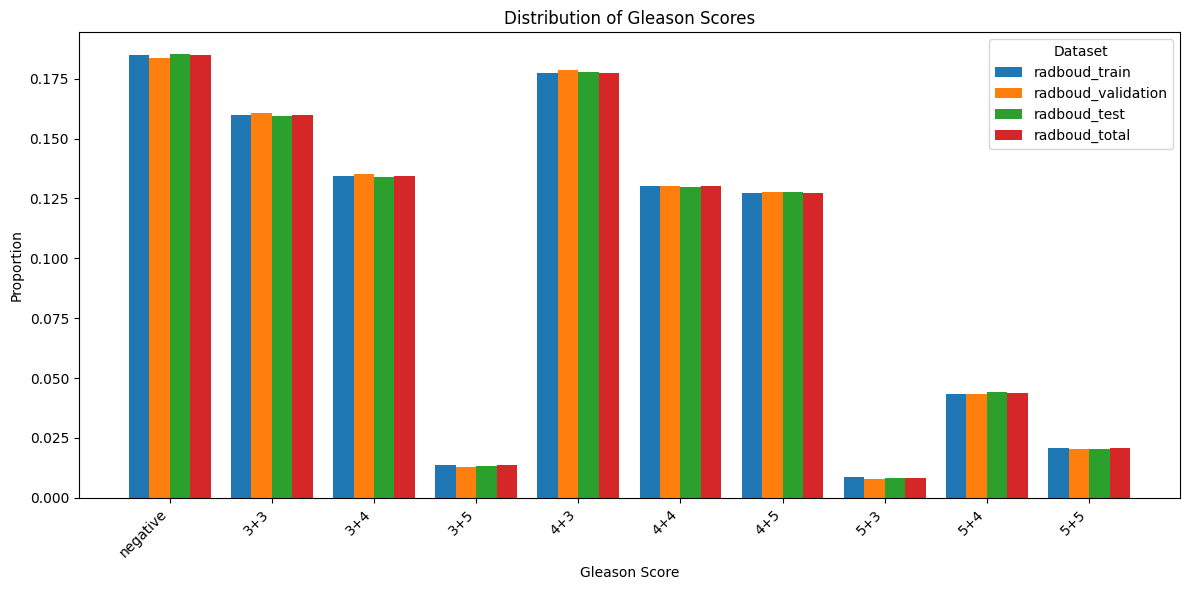

In [13]:
plot_gs_distr(dfs)

If Gleason score distributions match, carcinoma must match as well (we just add the non-negative cases).

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_binary_distr(dfs: dict[str, pd.DataFrame]) -> None:
    # Compute normalized value counts for each df
    counts_per_df = {name: df["carcinoma"].value_counts(normalize=True)
                      for name, df in dfs.items()}

    # Union of all categories across all dfs, sorted consistently (e.g. False, True)
    all_categories = set()
    for counts in counts_per_df.values():
        all_categories.update(counts.index)
    sorted_categories = sorted(all_categories, key=str)

    # Align each df's counts to the shared category order (missing -> 0)
    aligned = {
        name: counts.reindex(sorted_categories, fill_value=0)
        for name, counts in counts_per_df.items()
    }

    # Plot grouped bars
    n_groups = len(sorted_categories)
    n_series = len(dfs)
    x = np.arange(n_groups)
    total_width = 0.6
    bar_width = total_width / n_series

    plt.figure(figsize=(8, 6))
    for i, (name, values) in enumerate(aligned.items()):
        offset = (i - (n_series - 1) / 2) * bar_width
        plt.bar(x + offset, values.values, width=bar_width, label=name)

    plt.xlabel("Carcinoma")
    plt.ylabel("Fraction")
    plt.title("Carcinoma distribution")
    plt.xticks(x, [str(c) for c in sorted_categories])
    plt.legend(title="Dataset")
    plt.tight_layout()
    plt.show()

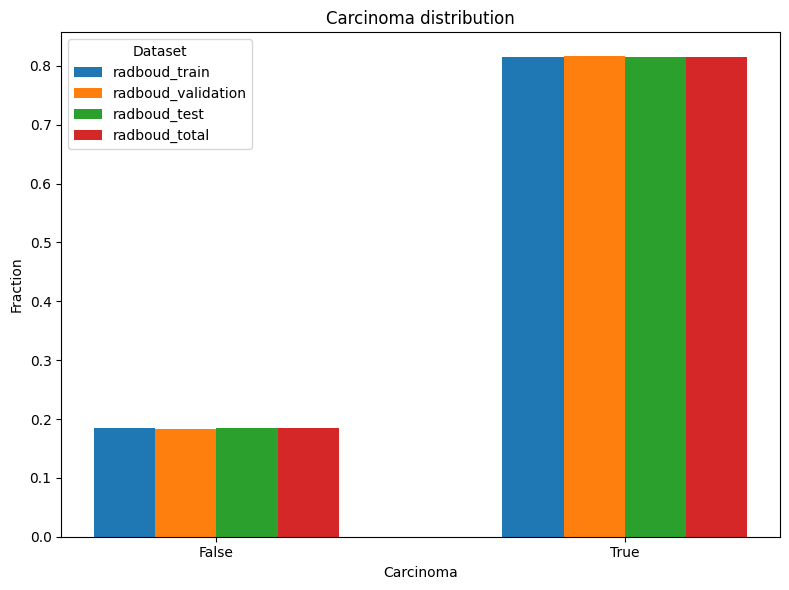

In [14]:
plot_binary_distr(dfs)

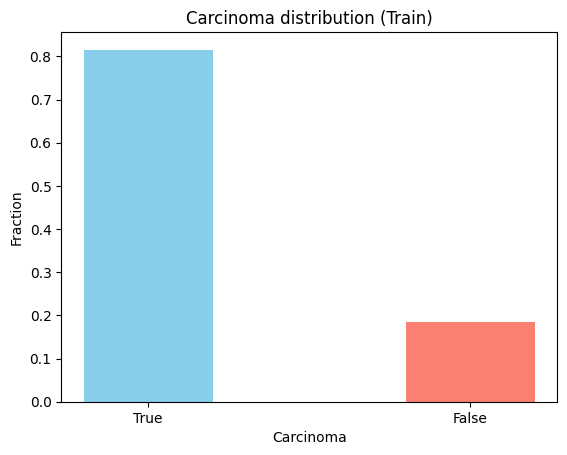

In [13]:
plot_binary_distr(radboud_train, "Train")

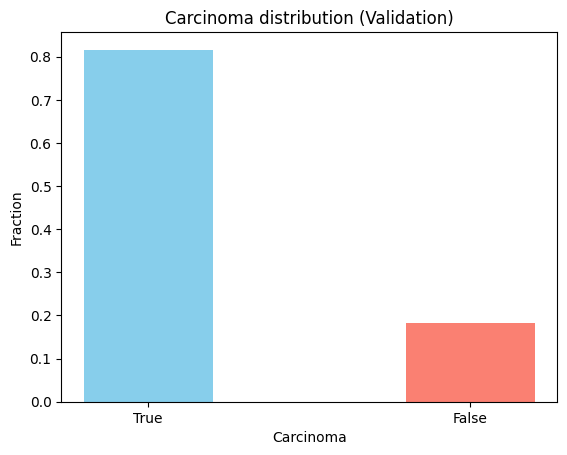

In [14]:
plot_binary_distr(radboud_val, "Validation")

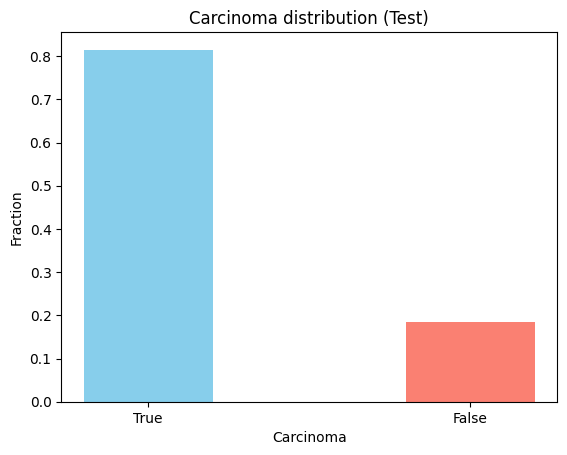

In [15]:
plot_binary_distr(radboud_test, "Test")

In [19]:
# check correspondance with nuclei graph split

nuclei_split = pd.read_csv( mlflow.artifacts.download_artifacts("mlflow-artifacts:/37/473a9b175e4e4f899f7f77314492bf11/artifacts/radboud_split/split.csv") )

In [17]:
train_ids = set(radboud_train["slide_id"]) | set( radboud_val["slide_id"] )
nuclei_train_ids = set( nuclei_split[ nuclei_split["set"] == "train" ]["slide_id"] )

assert len(train_ids) == len(nuclei_train_ids) == len( train_ids & nuclei_train_ids )

In [18]:
test_ids = set(radboud_test["slide_id"])
nuclei_test_ids = set( nuclei_split[ nuclei_split["set"] == "test" ]["slide_id"] )

assert len(test_ids) == len(nuclei_test_ids) == len( test_ids & nuclei_test_ids )